# "Trabalho 2": Fornecer subsídios descritivos para a análise dos Crimes Violentos Letais  Intencionais (CVLI) em Fortaleza 2009 a 2025

### 1. Importando as bibliotecas para o projeto

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Impotando as planilhas, salvando imagens e defindo os dados armazenando em variáveis

In [54]:
# Importando a planilha
df = pd.read_excel("../data/raw/CVLI_2009-a-2025.xlsx")

# Dados na qual iremos manipular armazenados em uma variável
tabela = df[["Natureza",
             "Meio Empregado",
             "Gênero",
             "Escolaridade da Vítima",
             "Raça da Vítima",
             "Idade da Vítima",
             "Data",
             "Hora",
             "Dia da Semana"]]

# Armazenando dados que talvez não iremos utilizar em outra variável
valores_excluidos_genericos = ['Não identificado', 'Não Informada']
valores_excluidos_meio = ['Meio não informado']

# Conversão da coluna de idade para número (a gente vai precisar desses dados limpos mais pra depois)
df['Idade da Vítima'] = pd.to_numeric(df['Idade da Vítima'], errors='coerce')


### 3. Seríes estáticas para:

*   Natureza
*   Meio Empregado
*   Gênero
*   Escolaridade da Vítima
*   Raça da Vítima
*   Dia Da Semana



In [55]:
# SÉRIES ESTÁTISTICAS - NATUREZA
freq_natureza = tabela["Natureza"].value_counts()
freq_natureza_rel = tabela["Natureza"].value_counts(normalize=True) * 100

serie_natureza = pd.DataFrame({
    "Frequência ": freq_natureza,
    "Frequência (%) ": freq_natureza_rel.round(2)
  })

serie_natureza

,Frequência,Frequência (%)
Natureza,,
HOMICIDIO DOLOSO,57367,96.68
ROUBO SEGUIDO DE MORTE (LATROCINIO),1003,1.69
LESAO CORPORAL SEGUIDA DE MORTE,689,1.16
FEMINICÍDIO,281,0.47


In [56]:
# SÉRIES ESTÁTISTICAS - MEIO EMPREGADO
freq_meio = tabela["Meio Empregado"].value_counts()
freq_meio_rel = tabela["Meio Empregado"].value_counts(normalize=True) * 100

serie_meio = pd.DataFrame({
    "Frequência: ": freq_meio,
    "Frequência (%): ": freq_meio_rel.round(2)

})
serie_meio

,Frequência:,Frequência (%):
Meio Empregado,,
Arma de fogo,49573,83.54
Arma branca,6071,10.23
Outros meios,3355,5.65
Meio não informado,341,0.57


In [57]:
# 8. SÉRIES ESTÁTISTICAS - GÊNERO
freq_genero = tabela["Gênero"].value_counts()
freq_genero_rel = tabela["Gênero"].value_counts(normalize=True) * 100

serie_genero = pd.DataFrame({
    "Frequência: ": freq_genero,
    "Frequência (%)": freq_genero_rel.round(2)
})
serie_genero

,Frequência:,Frequência (%)
Gênero,,
Masculino,54748,92.26
Feminino,4575,7.71
Não identificado,17,0.03


In [58]:
# 9. SÉRIES ESTÁTISTICAS - ESCOLARIDADE DA VÍTIMA
freq_escolaridade = tabela["Escolaridade da Vítima"].value_counts()
freq_escolaridade_rel = tabela["Escolaridade da Vítima"].value_counts(normalize=True) * 100

serie_escolaridade = pd.DataFrame({
    "Frequência: ": freq_escolaridade,
    "Frequência (%)": freq_escolaridade_rel.round(2)
})
serie_escolaridade

,Frequência:,Frequência (%)
Escolaridade da Vítima,,
Não Informada,16876,28.44
Alfabetizado,16798,28.31
Ensino Fundamental Incompleto,9379,15.81
Ensino Fundamental Completo,6458,10.88
Ensino Médio Completo,4457,7.51
Ensino Médio Incompleto,2620,4.42
Não Alfabetizado,2239,3.77
Superior Completo,273,0.46
Superior Incompleto,240,0.40


In [59]:
# 10. SÉRIES ESTÁTISTICAS - RAÇA DA VÍTIMA
freq_raca = tabela["Raça da Vítima"].value_counts()
freq_raca_rel = tabela["Raça da Vítima"].value_counts(normalize=True) * 100

serie_raca = pd.DataFrame({
    "Frequência: ": freq_raca,
    "Frequência (%)": freq_raca_rel.round(2)
})
serie_raca

,Frequência:,Frequência (%)
Raça da Vítima,,
Não Informada,46119,77.72
Parda,10888,18.35
Branca,1571,2.65
Preta,673,1.13
Indígena,48,0.08
Amarela,41,0.07


In [60]:
# 11. SÉRIES ESTÁTISTICAS - DIA DA SEMANA
freq_dia = tabela["Dia da Semana"].value_counts()
freq_dia_rel = tabela["Dia da Semana"].value_counts(normalize=True) * 100

serie_dia = pd.DataFrame({
    "Frequência: ": freq_dia,
    "Frequência (%)": freq_dia_rel.round(2)
})
serie_dia


,Frequência:,Frequência (%)
Dia da Semana,,
Domingo,11146,18.78
Sábado,10220,17.22
Sexta,7991,13.47
Segunda,7800,13.14
Quinta,7603,12.81
Quarta,7315,12.33
Terça,7265,12.24


### 4. Tabela cruzada com frequência simples para:


*   Meio Empregado x Gênero
*   Vítima x Raça da Vítima




In [61]:
#  Tabela cruzada com frequências simples para Meio Empregado x Gênero
tabela_meio_genero_simples = pd.crosstab(
    tabela['Meio Empregado'],
    tabela['Gênero']
)

ordem = tabela['Meio Empregado'].value_counts().index
tabela_meio_genero_simples = tabela_meio_genero_simples.loc[ordem]
tabela_meio_genero_simples

Gênero,Feminino,Masculino,Não identificado
Meio Empregado,,,
Arma de fogo,3323,46247,3
Arma branca,766,5304,1
Outros meios,445,2900,10
Meio não informado,41,297,3


In [62]:
# Tabela cruzada com frequência simples para Escolaridade da Vítima x Raça da Vítima

tabela_escolaridade_raca = pd.crosstab(
    tabela['Escolaridade da Vítima'],
    tabela['Raça da Vítima']
    )

ordem = tabela['Escolaridade da Vítima'].value_counts().index
tabela_escolaridade_raca = tabela_escolaridade_raca.loc[ordem]
tabela_escolaridade_raca

Raça da Vítima,Amarela,Branca,Indígena,Não Informada,Parda,Preta
Escolaridade da Vítima,,,,,,
Não Informada,0,88,0,16133,621,34
Alfabetizado,17,500,20,12080,3951,230
Ensino Fundamental Incompleto,6,335,10,6562,2318,148
Ensino Fundamental Completo,5,229,6,4485,1635,98
Ensino Médio Completo,6,227,4,3092,1080,48
Ensino Médio Incompleto,6,113,3,1799,652,47
Não Alfabetizado,1,52,3,1589,531,63
Superior Completo,0,17,2,198,53,3
Superior Incompleto,0,10,0,181,47,2


### 5. Tabela cruzada com frequência relativa (%) para:


*   Meio Empregado x Gênero
*   Escolaridade da Vítima x Raça da Vítima



In [63]:
# 13. Tabela cruzada com frequências relativa (%) para Meio Empregado x Gênero
tabela_meio_genero_rel = pd.crosstab(
    tabela['Meio Empregado'],
    tabela['Gênero'],
    normalize='index'
) * 100

ordem = tabela['Meio Empregado'].value_counts().index

tabela_meio_genero_rel = tabela_meio_genero_rel.loc[ordem]

tabela_meio_genero_rel.round(2)

Gênero,Feminino,Masculino,Não identificado
Meio Empregado,,,
Arma de fogo,6.70,93.29,0.01
Arma branca,12.62,87.37,0.02
Outros meios,13.26,86.44,0.30
Meio não informado,12.02,87.10,0.88


In [64]:
# 15. Tabela cruzada com frequência relativa (%) para Escolaridade da Vítima x Raça da Vítima
tabela_escolaridade_raca_rel = pd.crosstab(
    tabela["Escolaridade da Vítima"],
    tabela["Raça da Vítima"],
    normalize="index",
) * 100

ordem = tabela['Escolaridade da Vítima'].value_counts().index

tabela_escolaridade_raca_rel = tabela_escolaridade_raca_rel.loc[ordem]

tabela_escolaridade_raca_rel.round(2)

Raça da Vítima,Amarela,Branca,Indígena,Não Informada,Parda,Preta
Escolaridade da Vítima,,,,,,
Não Informada,0.00,0.52,0.00,95.60,3.68,0.20
Alfabetizado,0.10,2.98,0.12,71.91,23.52,1.37
Ensino Fundamental Incompleto,0.06,3.57,0.11,69.96,24.71,1.58
Ensino Fundamental Completo,0.08,3.55,0.09,69.45,25.32,1.52
Ensino Médio Completo,0.13,5.09,0.09,69.37,24.23,1.08
Ensino Médio Incompleto,0.23,4.31,0.11,68.66,24.89,1.79
Não Alfabetizado,0.04,2.32,0.13,70.97,23.72,2.81
Superior Completo,0.00,6.23,0.73,72.53,19.41,1.10
Superior Incompleto,0.00,4.17,0.00,75.42,19.58,0.83


### 6. Gráfico de setor para as variáveis:
*   Gênero
*   Meio Empregado


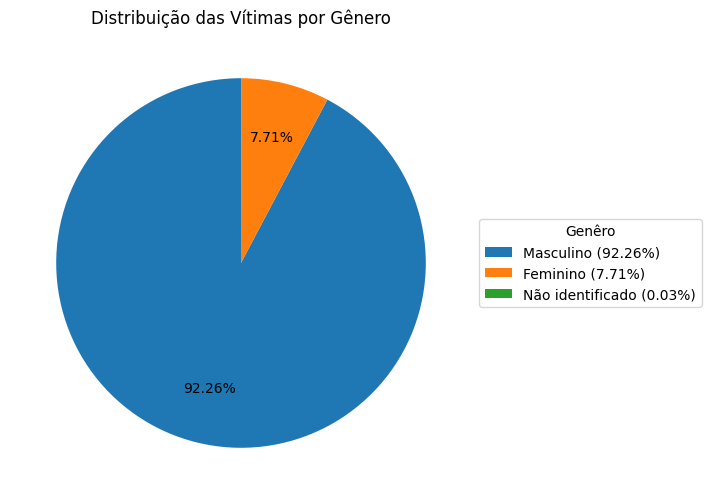

In [65]:
# 16. Gráfico de setor para Gênero
freq_genero = tabela["Gênero"].value_counts()

def autopct_limite(pct, limite=3):
    return f'{pct:.2f}%' if pct >= limite else ''

plt.figure(figsize=(10,6))

wedges, texts, autotexts = plt.pie(
    freq_genero,
    autopct=lambda pct: autopct_limite(pct, limite=3),
    startangle=90,
    pctdistance=0.7
)

plt.legend(
    wedges,
    [f"{label} ({pct:.2f}%)" for label, pct in zip(freq_genero.index, (freq_genero / freq_genero.sum() * 100))],
    title="Genêro",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Distribuição das Vítimas por Gênero")
plt.savefig("../reports/figures/grafico_genero.png", dpi=300, bbox_inches='tight')
plt.show()

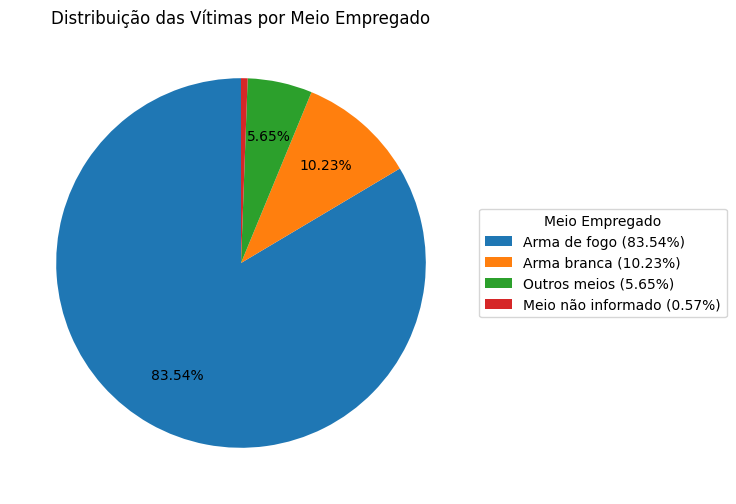

In [66]:
# 17. Gráfico de setor para Meio Empregado
freq_meio = tabela["Meio Empregado"].value_counts()

def autopct_limite(pct, limite=3):
    return f'{pct:.2f}%' if pct >= limite else ''

plt.figure(figsize=(10,6))

wedges, texts, autotexts = plt.pie(
    freq_meio,
    autopct=lambda pct: autopct_limite(pct, limite=3),
    startangle=90,
    pctdistance=0.7
)
plt.legend(
    wedges,
    [f"{label} ({pct:.2f}%)" for label, pct in zip(freq_meio.index, (freq_meio / freq_meio.sum() * 100))],
    title="Meio Empregado",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Distribuição das Vítimas por Meio Empregado")
plt.savefig("../reports/figures/grafico_meio_empregado.png", dpi=300, bbox_inches='tight')
plt.show()

### 7. Gráfico de barra para:


*   Dia da Semana
*   Escolaridade da Vítima



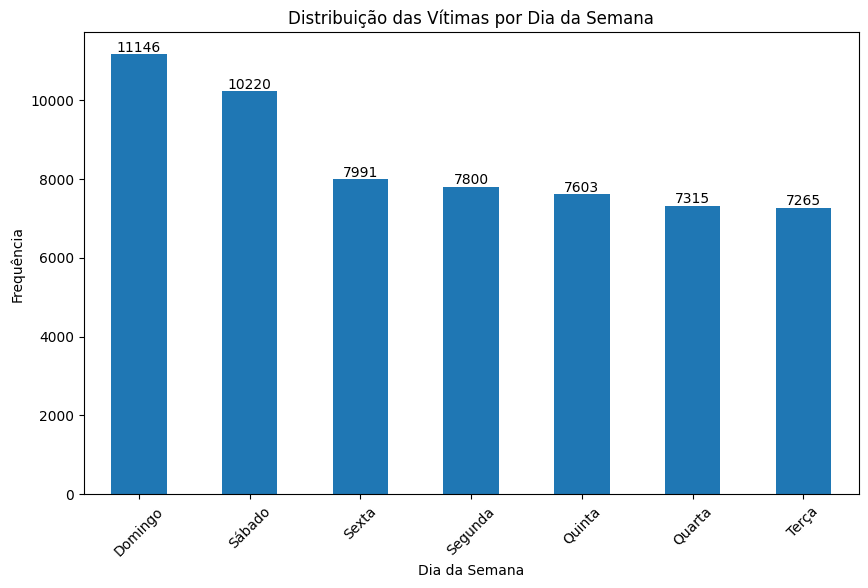

In [67]:
# 18. Gráfico de barra para Dia da Semana

freq_dia = tabela["Dia da Semana"].value_counts()

plt.figure(figsize=(10,6))
ax = freq_dia.plot(kind="bar")

plt.title("Distribuição das Vítimas por Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Frequência")
plt.xticks(rotation=45)

for i, valor in enumerate(freq_dia):
    ax.text(i, valor + 70, str(valor), ha="center")

plt.savefig("../reports/figures/grafico_dia_da_semana.png", dpi=300, bbox_inches='tight')
plt.show()


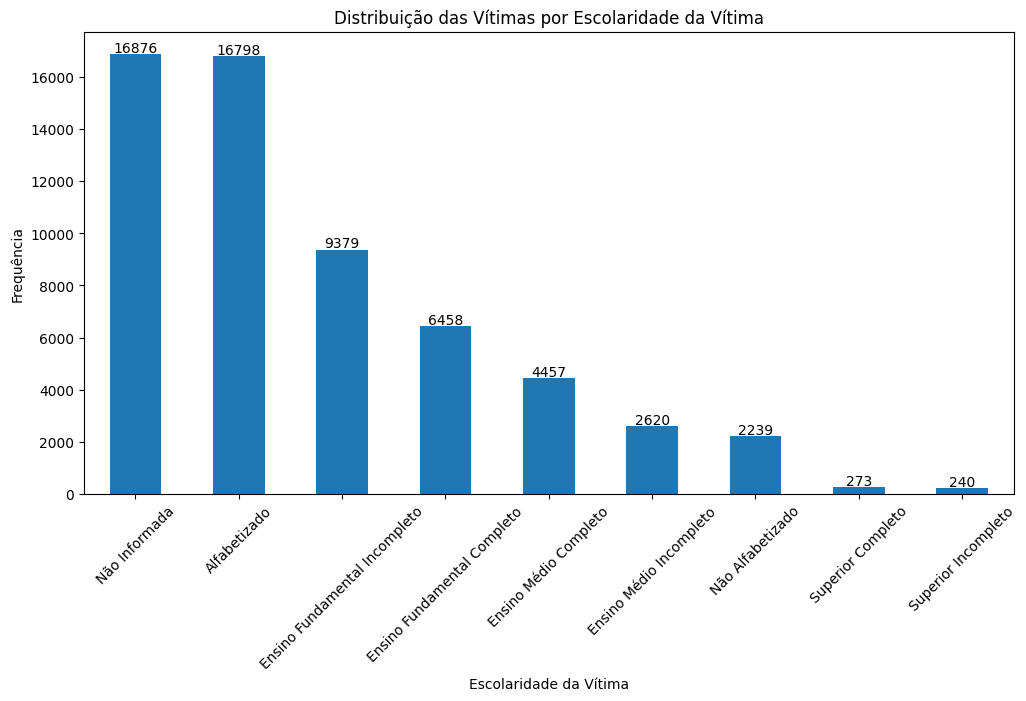

In [68]:
# 19. Gráfico de barra para Escolaridade da Vítima

freq_escolaridade = tabela["Escolaridade da Vítima"].value_counts()

plt.figure(figsize=(12,6))
ax = freq_escolaridade.plot(kind="bar")

plt.title("Distribuição das Vítimas por Escolaridade da Vítima")
plt.xlabel("Escolaridade da Vítima")
plt.ylabel("Frequência")
plt.xticks(rotation=45)

for i, valor in enumerate(freq_escolaridade):
  ax.text(i, valor + 70, str(valor), ha="center")

plt.savefig("../reports/figures/grafico_escolaridade.png", dpi=300, bbox_inches='tight')
plt.show()

### 8. Gráfico de Linha para:

*   Data em mês
*   Data em ano
*   Hora



C:\Users\morai\AppData\Local\Temp\ipykernel_20080\1353755283.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabela["Data"] = pd.to_datetime(tabela["Data"], errors="coerce")


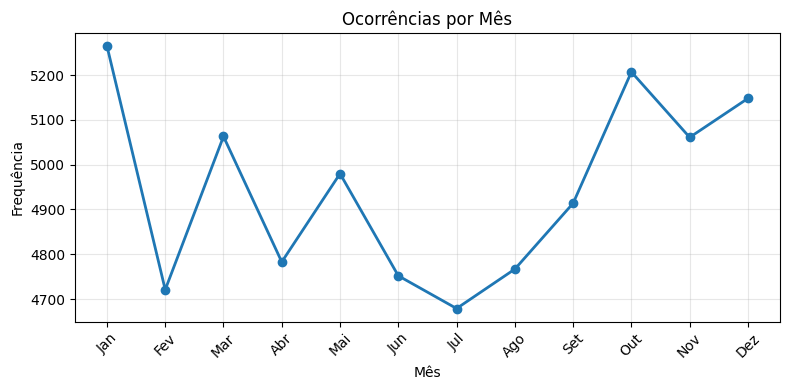

In [69]:
 # 20. Gráfico por linha para Data em mês
tabela["Data"] = pd.to_datetime(tabela["Data"], errors="coerce")

# dicionário de meses
meses = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr",
    5: "Mai", 6: "Jun", 7: "Jul", 8: "Ago",
    9: "Set", 10: "Out", 11: "Nov", 12: "Dez"
}

# frequência por mês
freq_mes = (
    tabela["Data"]
    .dt.month
    .value_counts()
    .sort_index()
)

# converter número do mês para nome
nomes_meses = [meses[m] for m in freq_mes.index]

# gráfico
plt.figure(figsize=(8,4))

plt.plot(
    nomes_meses,
    freq_mes.values,
    marker="o",
    linewidth=2
)

plt.title("Ocorrências por Mês")
plt.xlabel("Mês")
plt.ylabel("Frequência")

plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../reports/figures/grafico_ocorrencia.png", dpi=300, bbox_inches='tight')
plt.show()


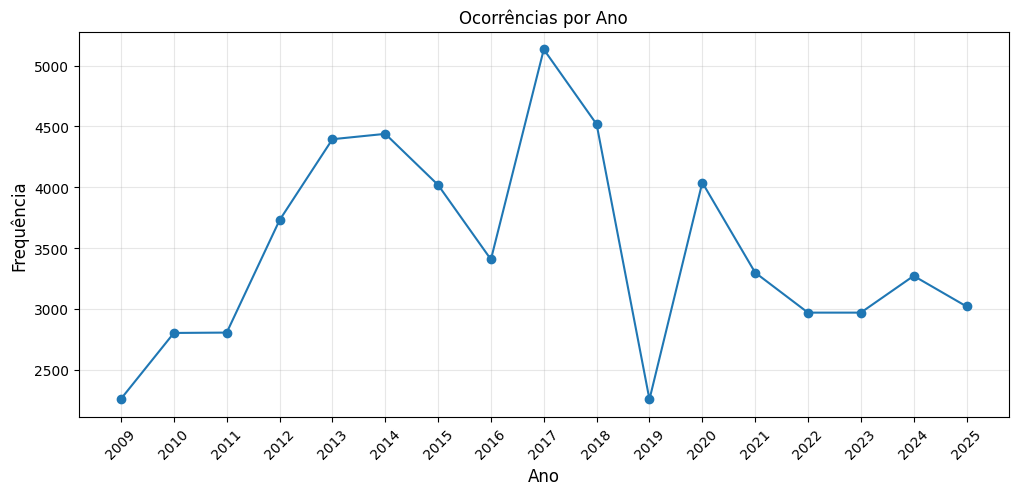

In [70]:
# 21. Gráfico por linha para Data em ano

freq_ano = tabela["Data"].dt.year.value_counts().sort_index()


plt.figure(figsize=(12,5))

plt.plot(
    freq_ano.index,
    freq_ano.values,
    marker='o'
)

plt.title("Ocorrências por Ano", fontsize=12)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.xticks(freq_ano.index)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.savefig("../reports/figures/grafico_ocorrencia_ano.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\morai\AppData\Local\Temp\ipykernel_20080\3268622513.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tabela["Hora"] = pd.to_datetime(tabela["Hora"])
C:\Users\morai\AppData\Local\Temp\ipykernel_20080\3268622513.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabela["Hora"] = pd.to_datetime(tabela["Hora"])


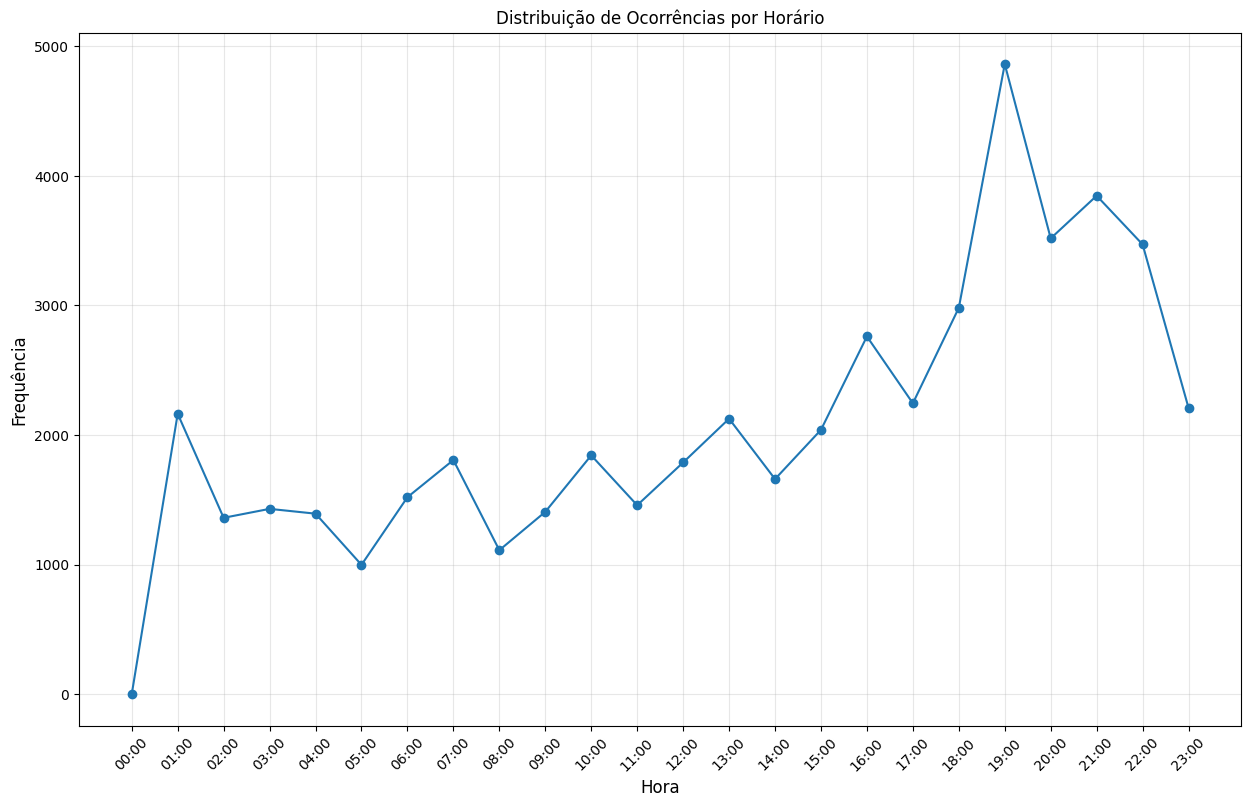

In [71]:
# 22. Gráfico por linha para Hora

tabela["Hora"] = pd.to_datetime(tabela["Hora"])
freq_hora = tabela["Hora"].dt.hour.value_counts().sort_index()

horas_extraidas = tabela["Hora"].dt.hour
horas_extraidas = horas_extraidas[horas_extraidas != 0]
hora_formatada = [f"{int(hora):02d}:00" for hora in freq_hora.index]

freq_hora = horas_extraidas.value_counts().sort_index()
freq_hora = freq_hora.reindex(range(24), fill_value=0)

plt.figure(figsize=(15, 9))
plt.plot(freq_hora.index, freq_hora.values, marker='o')
plt.xticks(range(24), hora_formatada, rotation=45)
plt.grid(True, alpha=0.3)
plt.title("Distribuição de Ocorrências por Horário", fontsize=12)
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.savefig("../reports/figures/grafico_ocorrencia_hora.png", dpi=300, bbox_inches='tight')
plt.show()

### 9. Medidas de posição e separatriz para:

*   Idade da Vítima




In [72]:
# 23. Medidas de dispersão para Idade da Vítima

tabela["Idade da Vítima"] = pd.to_numeric(tabela["Idade da Vítima"], errors="coerce")

estatisticas = pd.DataFrame({
    "Medida": ["Média", "Mediana", "Moda", "Valores nulos"],
    "Valor": [
        round(tabela["Idade da Vítima"].mean(), 2),
        tabela["Idade da Vítima"].median(),
        tabela["Idade da Vítima"].mode().iloc[0],
        tabela["Idade da Vítima"].isna().sum()
    ]
})

estatisticas

C:\Users\morai\AppData\Local\Temp\ipykernel_20080\250011063.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabela["Idade da Vítima"] = pd.to_numeric(tabela["Idade da Vítima"], errors="coerce")


,Medida,Valor
0,Média,29.82
1,Mediana,27.00
2,Moda,20.00
3,Valores nulos,5134.00


In [73]:
# 24.1 Medida de separatriz para Idade da Vítima

tabela["Idade da Vítima"].quantile([0.25, 0.5, 0.75])


0.25    21.0
0.50    27.0
0.75    36.0
Name: Idade da Vítima, dtype: float64

In [74]:
# 24.2
tabela["Idade da Vítima"].quantile([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])

0.1    17.0
0.2    20.0
0.3    22.0
0.4    24.0
0.5    27.0
0.6    30.0
0.7    34.0
0.8    39.0
0.9    47.0
Name: Idade da Vítima, dtype: float64

In [75]:
# 24.3
float(tabela["Idade da Vítima"].quantile(0.9))

47.0

### 10. Medidas de dispersão para:

*   Idade da Vítima
   



In [76]:
# 25. Medidas de dispersão para Idade da Vítima

variancia = tabela["Idade da Vítima"].var()
desvio_padrao = tabela["Idade da Vítima"].std()
media = tabela["Idade da Vítima"].mean()
coef_variacao = (desvio_padrao / media) * 100

tabela_disp = pd.DataFrame({
    "Medida": ["Variância", "Desvio padrão", "Coeficiente de variação (%)"],
    "Valor": [variancia, desvio_padrao, coef_variacao]
})

tabela_disp.round(2)




,Medida,Valor
0,Variância,148.22
1,Desvio padrão,12.17
2,Coeficiente de variação (%),40.83


### 11. Boxplot
*   Idade da Vítima



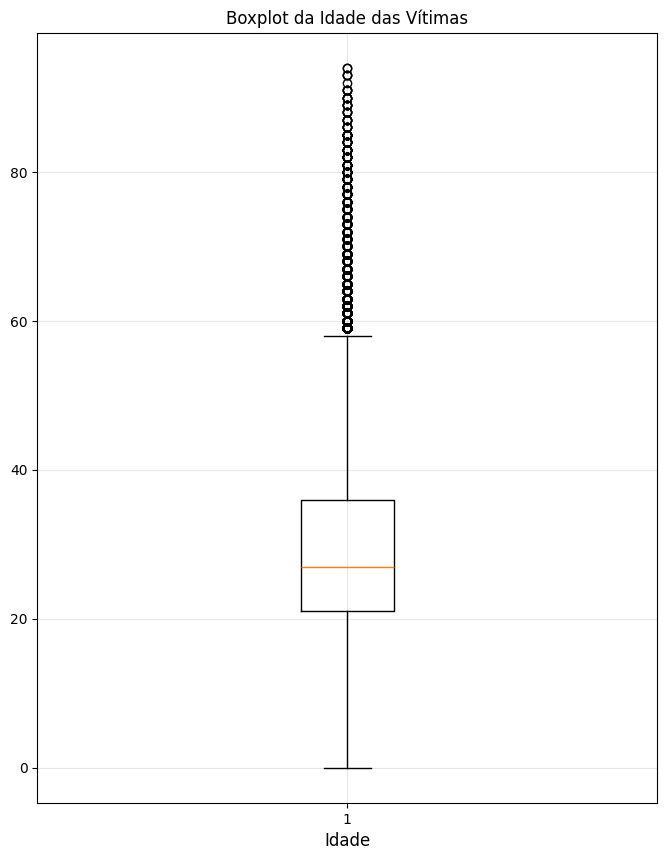

In [77]:
# 26. BoxPlot

idades_validas = tabela[tabela["Idade da Vítima"] > 0]["Idade da Vítima"]
idades_validas = tabela[tabela["Idade da Vítima"] < 100]["Idade da Vítima"]

plt.figure(figsize=(8, 10))
plt.boxplot(idades_validas)

plt.title("Boxplot da Idade das Vítimas", fontsize=12)

plt.xlabel("Idade", fontsize=12)
plt.grid(True, alpha=0.3)

plt.savefig("../reports/figures/bloxplot1.png", dpi=300, bbox_inches='tight')
plt.show()

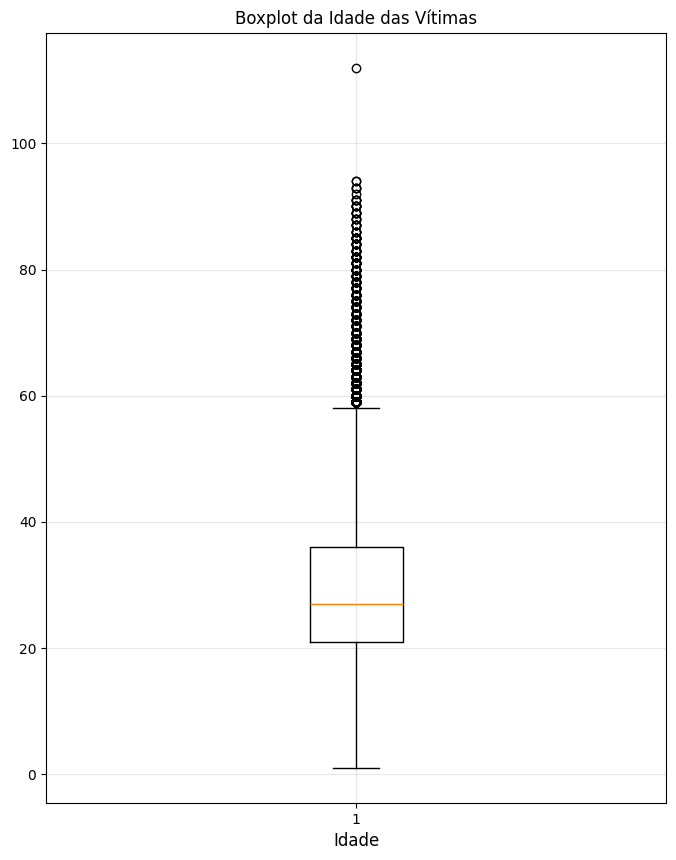

In [78]:
# 26. BoxPlot

idades_validas = tabela[tabela["Idade da Vítima"] > 0]["Idade da Vítima"]


plt.figure(figsize=(8, 10))
plt.boxplot(idades_validas)

plt.title("Boxplot da Idade das Vítimas", fontsize=12)

plt.xlabel("Idade", fontsize=12)
plt.grid(True, alpha=0.3)

plt.savefig("../reports/figures/bloxplot2.png", dpi=300, bbox_inches='tight')
plt.show()